In [36]:
import sys
!{sys.executable} -m pip install geopy

  Using cached geopy-2.4.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached geographiclib-2.1-py3-none-any.whl.metadata (1.6 kB)

   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   ---------------------------------------- 2/2 [geopy]



In [ ]:
#import lib
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve, auc
from imblearn.over_sampling import SMOTE
from geopy.distance import geodesic
import joblib

In [ ]:
df = pd.read_csv("dataset.csv")
df.head()

In [ ]:
df.tail()

**Handing transaction date and time**

In [65]:
# extracting hours,days,months form the transaction date, time column
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['hour'] = df['trans_date_trans_time'].dt.hour
df['day'] = df['trans_date_trans_time'].dt.day
df['month'] = df['trans_date_trans_time'].dt.month

**Drop the irrelevant features**

In [66]:
drop_columns = ['Unnamed: 0', 'trans_date_trans_time', 'first', 'last', 'street', 'city', 'state', 'zip', 'dob', 'job', 'trans_num']
df = df.drop(columns = drop_columns)

In [67]:
df.head()

,cc_num,merchant,category,amt,gender,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud,hour,day,month
0,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,36.0788,-81.1781,3495,1325376018,36.011293,-82.048315,0,0,1,1
1,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,48.8878,-118.2105,149,1325376044,49.159047,-118.186462,0,0,1,1
2,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,M,42.1808,-112.2620,4154,1325376051,43.150704,-112.154481,0,0,1,1
3,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,46.2306,-112.1138,1939,1325376076,47.034331,-112.561071,0,0,1,1
4,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,M,38.4207,-79.4629,99,1325376186,38.674999,-78.632459,0,0,1,1


**Handing Category columns**

In [68]:
#using labelencoder to encoder the categories into numrical format
cat_col = ['merchant', 'category', 'gender']
encoders = {}
for col in cat_col:
    encoders[col]= LabelEncoder()
df[col]= encoders[col].fit_transform(df[col])

**Calculate the distance between transactions**

In [ ]:
#function for distance between transaction location and merchant location
def haversine(lat1,lon1,lat2,lon2):
     return np.array([geodesic((a,b),(c,d)).km for a,b,c,d in zip (lat1,lon1,lat2,lon2)])
#creating a seperate column for distance 
df['distance'] = haversine(df['lat'], df['long'], df['merch_lat'], df['merch_long'])

In [58]:
df.head()

,cc_num,merchant,category,amt,gender,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud,hour,day,month,distance
0,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,0,36.0788,-81.1781,3495,1325376018,36.011293,-82.048315,0,0,1,1,78.773821
1,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,0,48.8878,-118.2105,149,1325376044,49.159047,-118.186462,0,0,1,1,30.216618
2,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,1,42.1808,-112.2620,4154,1325376051,43.150704,-112.154481,0,0,1,1,108.102912
3,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,1,46.2306,-112.1138,1939,1325376076,47.034331,-112.561071,0,0,1,1,95.685115
4,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,1,38.4207,-79.4629,99,1325376186,38.674999,-78.632459,0,0,1,1,77.702395


**Features for training the model**

In [59]:
features = ['merchant', 'category', 'amt', 'cc_num', 'hour', 'day', 'month', 'gender', 'distance']
x = df[features]
y = df['is_fraud']

**Graph to show data imbalance**

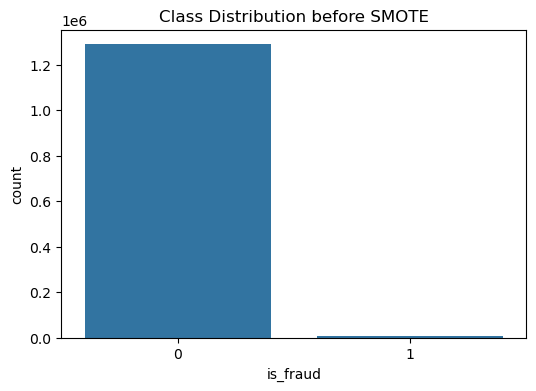

In [60]:
# before balancing
plt.figure(figsize = (6,4))
sns.countplot(x= 'is_fraud', data = df)
plt.title("Class Distribution before SMOTE")
plt.show()

**Balancing data using SMOTE(oversampling)**

In [61]:
smote = SMOTE(random_state = 42)
x_resample, y_resample = smote.fit_resample(x,y)

ValueError: could not convert string to float: 'fraud_Rippin, Kub and Mann'

**Graph to show data balance**

In [ ]:
#after balancing
plt.figure(figsize = (6,4))
sns.countplot(x=y_resample)
plt.title("Class Distribution after SMOTE")
plt.show()

**Split data into TRAINING AND TESTING data**

In [ ]:
x_train,x_test,y_train,y_test = tain_test_split(x_resample, y_resample, test_size = 0.2, random_sate =42)

**Train model using RANDOM FOREST ALGORITHM**

In [ ]:
rf_model = RandomForestClassificatier(
    boosting_type = 'gbdf',
    objective = 'binary',
    metrics = 'auc',
    is_unbalance = True,
    learning_rate = 0.05,
    num_leaves = 31,
    max_depth = 1,
    n_estimator = 200
)
#fit train data in model
rf_model.fit(x_train,y_train)

**Make Prediction**

In [ ]:
y_pred = model.predict(x_test)

**Evaluate Model**

In [1]:
print("Classification_Report : \n" classification_report(y_test,y_pred))
print("Roc AUC Score : ", roc_auc_score(y_test,y_pred))

SyntaxError: invalid syntax. Perhaps you forgot a comma? (1027826006.py, line 1)

In [ ]:
d